# Part I: Taylor expansions (60 points)

Given the function 

$f(x,y)=\frac{x^3}{3}-9a^2x+5ay^2-xy^2,$ 

please sum all the digits in your student ID number and use the resulting value as `a` in the function. Complete problems 1-6 below using this customized function.

For example, if your student ID is 1001001, then the value of your `a` is 1+0+0+1+0+0+1 = 3, and your customized function would be

$f(x, y) = \frac{x^3}{3} - 9 \times 3^2 x + 5 \times 3 y^2 - xy^2 = \frac{x^3}{3} - 81x + 15y^2 - xy^2.$

In [11]:
std_id = [1, 0, 0, 6, 6, 1, 7]
print(f"a = {sum(std_id)}")

a = 21



# 1. Compute $f(x,y)$ using your own student ID. 
$$\text{Student ID}= 1006617$$

\begin{align*} f(x,y)&=\frac{x^3}{3}-9\times 21^2x+5\times 21 y^2-xy^2 \\ 
&= \frac{x^3}{3} - 3969x + 105y^2-xy^2 \end{align*}

# 2. Plot $f(x,y)$ and its contour lines (5 points)

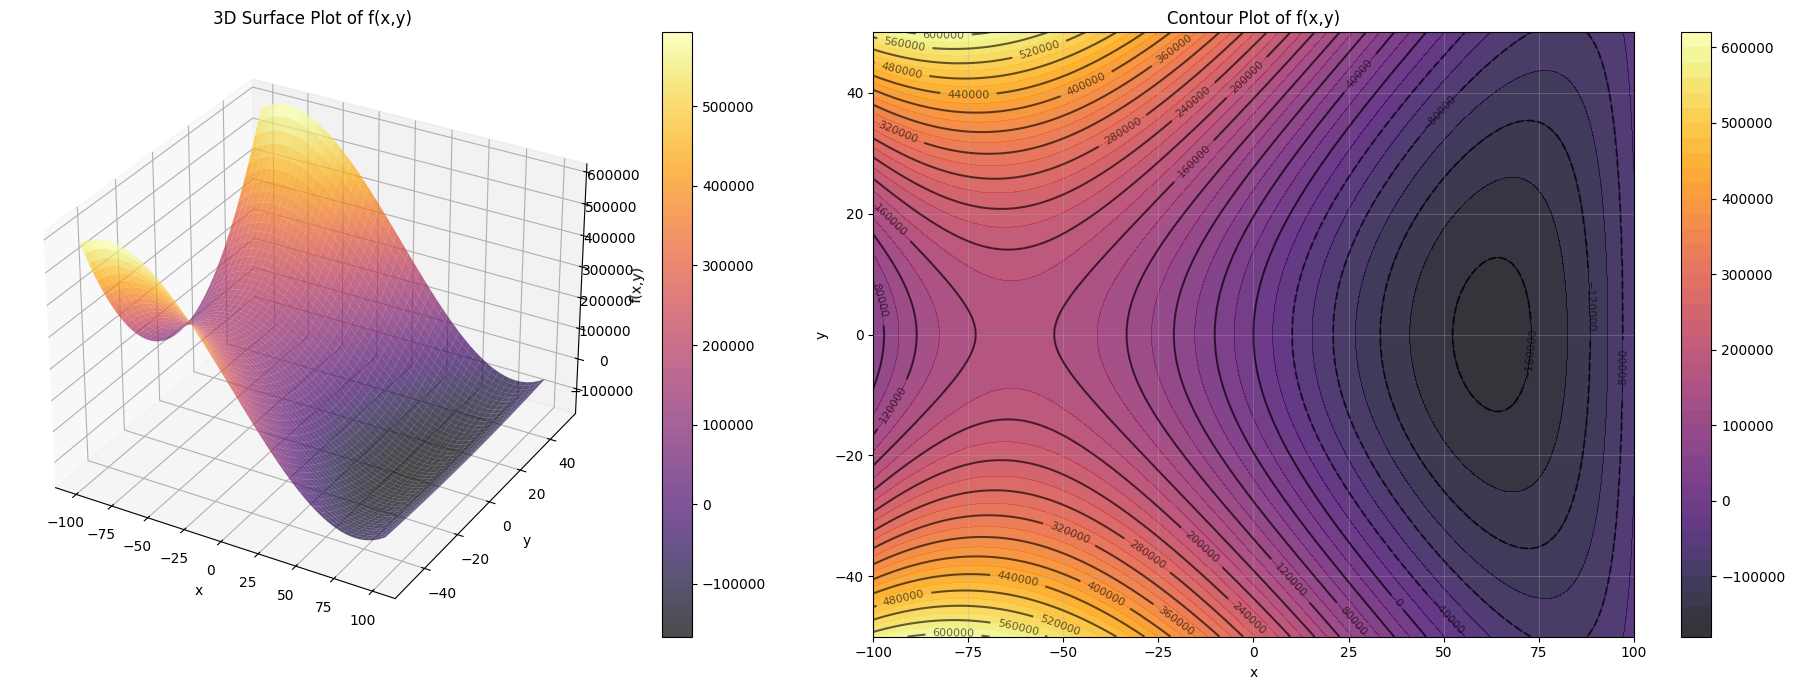

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def myfunc(x: int, y: int) -> int:
    """
    where f(x,y) = x³/3 - 3969x + 105y² - xy²
    """
    return (x**3/3 - 3969*x + 105*y**2 - x*y**2)

x = np.linspace(-100, 100, 400)
y = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x, y)

Z = myfunc(X, Y)

fig = plt.figure(figsize=(20, 7))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='inferno', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Surface Plot of f(x,y)')
fig.colorbar(surf, ax=ax1)

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20, colors='black', alpha=0.6)
contourf = ax2.contourf(X, Y, Z, levels=50, cmap='inferno', alpha=0.8)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot of f(x,y)')
ax2.grid(True, alpha=0.3)
fig.colorbar(contourf, ax=ax2)

plt.tight_layout()
plt.show()

## Both $f(x,y)$ and contour lines in same plot

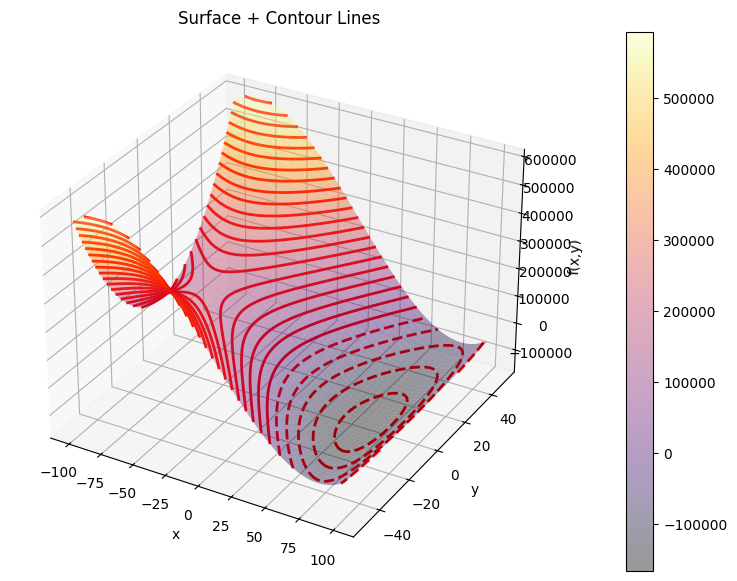

In [13]:
fig = plt.figure(figsize=(20, 7))

ax3 = plt.axes(projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='inferno', alpha=0.4)
contour3 = ax3.contour3D(X, Y, Z, levels=30, colors='red', linewidths=2)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('f(x,y)')
ax3.set_title('Surface + Contour Lines')

fig.colorbar(surf3, ax=ax3)

plt.show()

# 3. Compute the partial derivative of $f(x,y)$ with respect to $x$ and $y$ (5 points)

$${\partial f \over \partial x} = x^2 - 3969 - y^2$$
$${\partial f \over \partial y}= 210y - 2xy$$

# 4. Compute the first order Taylor approximation of $f(x,y)$ at point $(0,1)$ (5 points)

We have 
\begin{align*}
f(0,1) &= \frac{0^3}{3} - 3969(0) + 105(1)^2 - 0(1)^2 \\
&= 105
\end{align*}

and 


\begin{align*}
\nabla f(0,1) &= \left( \frac{\partial f}{\partial x} \bigg\rvert_{(0,1)},\; \frac{\partial f}{\partial y} \bigg\rvert_{(0,1)} \right)^\top \\
&= \left(0^2 - 3969 - 1^2,\; 210(1) - 2(0)(1)\right)^\top \\
&= (-3970, \; 210)^\top
\end{align*}


So the first-order taylor at (0,1) is 

\begin{align*}
T_{1,(0,1)}(x,y) &= f(0,1) + \big\langle \nabla f(0,1), \; (x,y) - (0,1) \big\rangle \\
&= f(0,1) + \big\langle \nabla f (0,1), \; (x-0, y-1) \big\rangle \\
&= 105 + \begin{pmatrix} -3970 \\ 210 \end{pmatrix} \cdot \begin{pmatrix} x \\ y - 1 \end{pmatrix} \\
&= 105 + (-3970x + 210y - 210) \\
&= 210y-3970x-105
\end{align*}

# 5. Plot the first order Taylor approximation at point $(0,1)$ (5 points)

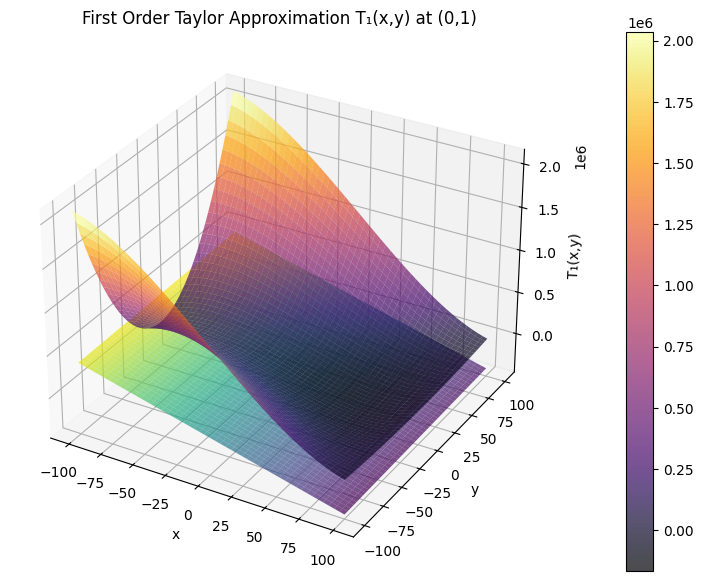

In [23]:
def t1_taylor(x: int,y: int) -> int:
    """ 
    First order Taylor approximation at (0,1) is:
    T_{1, (0,1)}(x.y) = 210y - 3970x -105
    """
    return -105 - 3970*x + 210*y

x = np.linspace(-100, 100, 400)
y = np.linspace(-100, 100, 400)
X, Y = np.meshgrid(x, y)

Z = myfunc(X, Y)
Z_taylor = t1_taylor(X, Y)

fig = plt.figure(figsize=(20, 7))

ax4 = fig.add_subplot(111, projection='3d')
surf4 = ax4.plot_surface(X, Y, Z, cmap='inferno', alpha=0.7, label="f(x,y)")
surf5 = ax4.plot_surface(X, Y, Z_taylor, cmap='viridis', alpha=0.7, label="Taylor T₁(x,y)")
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('T₁(x,y)')
ax4.set_title('First Order Taylor Approximation T₁(x,y) at (0,1)')
fig.colorbar(surf4, ax=ax4)
plt.show()

# 6. Compute the Hessian matrix of $f(x,y)$ at point $(0,1)$ (5 points)

First we calculate the individual Hessian entries:

\begin{align*}
\frac{\partial^2 f}{\partial x^2} &= 2x, & \frac{\partial^2 f}{\partial x \partial y} &= -2y \\
\frac{\partial^2 f}{\partial y \partial x} &= -2y, & \frac{\partial^2 f}{\partial y^2} &= 210-2x \\
\end{align*}


Then we evaluate the Hessian at $(0,1)$:

\begin{align*}
\nabla^2f(0,1) &= \begin{pmatrix} \frac{\partial^2 f}{\partial x^2}\big\vert_{(0,1)} & \frac{\partial^2 f}{\partial x \partial y}\big\vert_{(0,1)} \\ \frac{\partial^2 f}{\partial y \partial x}\big\vert_{(0,1)} & \frac{\partial^2 f}{\partial y^2}\big\vert_{(0,1)} \end{pmatrix} \\
&= \begin{pmatrix} 2(0) & -2(1) \\ -2(1) & 210 - 2(0) \end{pmatrix} \\ 
&= \begin{pmatrix} 0 & -2 \\ -2 & 210 \end{pmatrix}
\end{align*}

# 7. Compute the second order Taylor approximation of $f(x,y)$ at point $(0,1)$ (5 points)

The second order Taylor approximation is given by:

\begin{align*}
T_{2,(0,1)}(x,y)&= f(0,1) + \langle \nabla f(0,1) , \left((x,y) - (0,1)\right) \rangle + \frac{1}{2} ((x,y)-(0,1))^\top \nabla^2 f(0,1) ((x,y) - (0,1)) \\
&= T_{1,(0,1)}(x,y) + \frac{1}{2} ((x,y)-(0,1))^\top \nabla^2 f(0,1) ((x,y) - (0,1))
\end{align*}


Where we will re-use the expression from the First-order Taylor approximation from above. Now to calculate the term at the back:

\begin{align*}
T_{2,(0,1)}(x,y)&= T_{1,(0,1)}(x,y) + \frac{1}{2} ((x,y)-(0,1))^\top \nabla^2 f(0,1) ((x,y) - (0,1)) \\
&= T_{1,(0,1)}(x,y) + \frac{1}{2} \begin{pmatrix} x & y-1\end{pmatrix} \begin{pmatrix} 0 & -2 \\ -2 & 210 \end{pmatrix} \begin{pmatrix}x \\ y-1\end{pmatrix} \\
&= T_{1,(0,1)}(x,y) + \frac{1}{2}\left( -2xy + 2x -420y + 210 + 210y^2 \right) \\
&= 210y - 3970x - 105 - 2xy + 2x -210y + 105 + 105y^2 \\
&= -3968x - 2xy + 105y^2
\end{align*}

# 8. Plot the second order Taylor approximation at point $(0,1)$ (5 points)

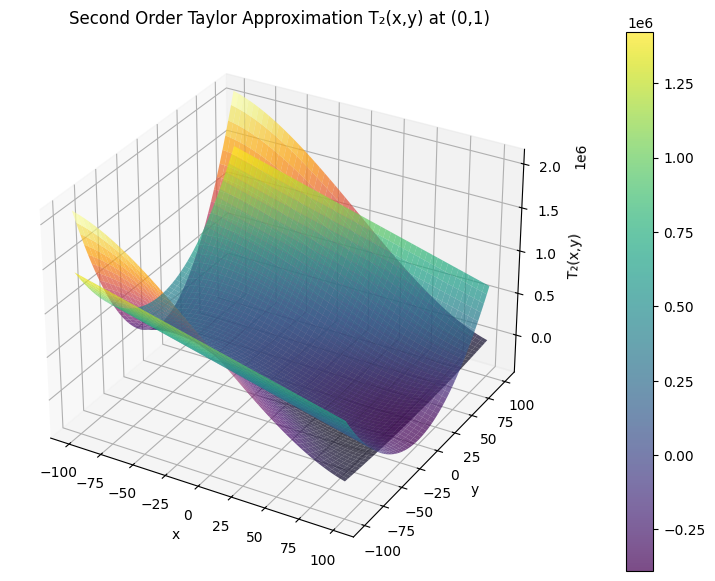

In [24]:
def t2_taylor(x: int,y: int) -> int:
    """ 
    Second order Taylor approximation at (0,1) is:
    T_{2, (0,1)}(x,y) = -3968x - 2xy + 105y^2
    """
    return -3968*x - 2*x*y + 105*y**2

x = np.linspace(-100, 100, 400)
y = np.linspace(-100, 100, 400)
X, Y = np.meshgrid(x, y)

Z = myfunc(X, Y)
Z_taylor2 = t2_taylor(X, Y)

fig = plt.figure(figsize=(20, 7))
ax4 = fig.add_subplot(111, projection='3d')
surf4 = ax4.plot_surface(X, Y, Z, cmap='inferno', alpha=0.7, label="f(x,y)")
surf4 = ax4.plot_surface(X, Y, Z_taylor2, cmap='viridis', alpha=0.7, label="Taylor T₂(x,y)")
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('T₂(x,y)')
ax4.set_title('Second Order Taylor Approximation T₂(x,y) at (0,1)')
fig.colorbar(surf4, ax=ax4)
plt.show()


# 9. Compute all the critical points of $f(x,y)$ (5 points)

Critical points occur when the gradient is 0, i.e.

$$\nabla f(x,y) = \begin{pmatrix} 0 & 0 \end{pmatrix}$$

where

\begin{align}
\frac{\partial f}{\partial x} &= x^2 - 3969 - y^2 = 0 \\
\frac{\partial f}{\partial y} &= 210y - 2xy = 0
\end{align}


From equation (2), we have:

\begin{align*}
(210-2x)y = 0 \\
\Longrightarrow y= 0 \; \text{or} \; x = 105
\end{align*}


With these 2 cases, we have first for $y=0$:

\begin{align*}
x^2 &= 3969 \\
x &= \pm 63 \\
\Longrightarrow \; & (63, 0), \; (-63,0)
\end{align*}


Then for $x=105$ we have:

\begin{align*}
105^2 - 3969 &= y^2 \\
y^2 &= 7056 \\
y &= \pm 84 \\
\Longrightarrow \; & (105, 84), \; (105, -84)
\end{align*}

The critical points are: $(63, 0), \; (-63, 0), \; (105, 84),\; (105, -84)$.

# 10. Plot all the critical points of $f(x,y)$ (together with the graph of the function) (5 points)

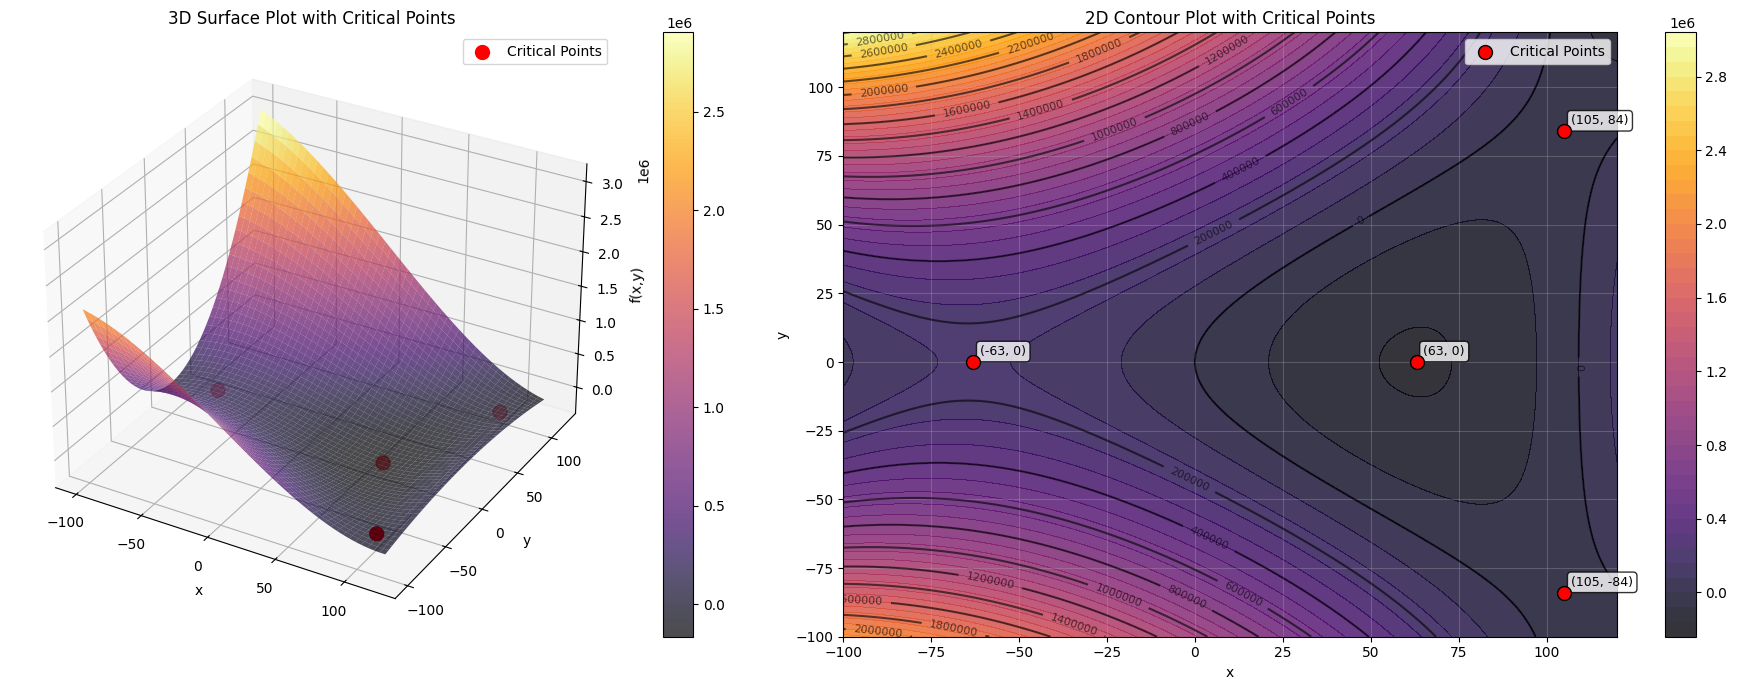

In [16]:
critical_points = [(63, 0), (-63, 0), (105, 84), (105, -84)]
critical_x = [point[0] for point in critical_points]
critical_y = [point[1] for point in critical_points]
critical_z = [myfunc(point[0], point[1]) for point in critical_points]

x = np.linspace(-100, 120, 400)
y = np.linspace(-100, 120, 400)
X, Y = np.meshgrid(x, y)

Z = myfunc(X, Y)

fig = plt.figure(figsize=(20, 7))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='inferno', alpha=0.7)

ax1.scatter(critical_x, critical_y, critical_z, color='red', s=100, 
           label='Critical Points', zorder=5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Surface Plot with Critical Points')
ax1.legend()
fig.colorbar(surf, ax=ax1)

ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20, colors='black', alpha=0.6)
contourf = ax2.contourf(X, Y, Z, levels=50, cmap='inferno', alpha=0.8)
ax2.clabel(contour, inline=True, fontsize=8)

ax2.scatter(critical_x, critical_y, color='red', s=100, 
           label='Critical Points', zorder=5, edgecolors='black')

# adding labels for each point
for i, (x, y) in enumerate(critical_points):
    ax2.annotate(f'({x}, {y})', (x, y), xytext=(5, 5), 
                textcoords='offset points', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('2D Contour Plot with Critical Points')
ax2.grid(True, alpha=0.3)
ax2.legend()
fig.colorbar(contourf, ax=ax2)

plt.tight_layout()
plt.show()

# 11. Compute all the eigenvalues of Hessian at point $(3a,0)$ (5 points)

Given the hessian from before:

\begin{align*}
\nabla^2 f(x,y) &= \begin{pmatrix} 2x & -2y \\ -2y & 210-2x\end{pmatrix} \\
\nabla^2 f(3a,0) &= \begin{pmatrix} 6a & 0 \\ 0 & 210-6a \end{pmatrix}
\end{align*}

Since the hessian at point $(3a,0)$ is diagonal, the eigenvalues are just the diagonal elements, so they are: $\lambda_1 = 6a$, and $\lambda_2 = 210-6a = 6(35-a)$.

# 12. Classify the type (saddle/local minimum/local maximum) of $(3a, 0)$ (5 points)

The type of $(3a,0)$ depends on the value of $a$:

1. When $0 < a < 35$, we have $\lambda_1 > 0$ and $\lambda_2 > 0$, so $(3a,0)$ is a **local minimum** (PSD).
2. When $a = 35$, we have $\lambda_2 = 0$, which is **degenerate (inconclusive)**
3. When $a > 35$, we have $\lambda_1 > 0$ and $\lambda_2 < 0$, so this is a **saddle point**.
4. When $a < 0$, we have $\lambda_1 < 0$ and $\lambda_2 > 0$, so this is also a **saddle point**

# 13. Plot the univariate restriction of f along the two eigenvectors of the Hessian at the point $(3a,0)$ (5 points)

In [17]:
def hessian_at_point(x: int, y: int) -> np.ndarray:
    """
    Calculate Hessian at point (x, y)
    """
    fxx = 2*x
    fyy = 210 - 2*x
    fxy = -2*y
    return np.array([[fxx, fxy], [fxy, fyy]])

a = 21
x0, y0 = 3*a, 0 # for point (63,0)

H = hessian_at_point(x0, y0)
eigenvalues, eigenvectors = np.linalg.eig(H)

print(f"\nHessian at ({x0}, {y0}):")
print(H)
print(f"\nEigenvalues: λ₁ = {eigenvalues[0]:.2f}, λ₂ = {eigenvalues[1]:.2f}")
print(f"\nEigenvectors:")
print(f"v₁ = {eigenvectors[:, 0]} (corresponds to λ₁ = {eigenvalues[0]:.2f})")
print(f"v₂ = {eigenvectors[:, 1]} (corresponds to λ₂ = {eigenvalues[1]:.2f})")


Hessian at (63, 0):
[[126   0]
 [  0  84]]

Eigenvalues: λ₁ = 126.00, λ₂ = 84.00

Eigenvectors:
v₁ = [1. 0.] (corresponds to λ₁ = 126.00)
v₂ = [0. 1.] (corresponds to λ₂ = 84.00)


## Eigenvector analysis

For univariate restriction, we are looking at the function $f(x,y)$ along a specific direction, so we parameterise along an eigenvector $v$ starting from point $(3a,0)$:
- $(x,y) = (3a,0) + t \cdot v$ where $t$ is a scalar

Since the Hessian is **diagonal**, the eigenvectors are just $\begin{bmatrix} 1 & 0 \end{bmatrix}$ (x-direction) and $\begin{bmatrix} 0 & 1 \end{bmatrix}$ (y-direction) as shown in the code above with *numpy*. Now we plot the curves below, where we set $a=21$:

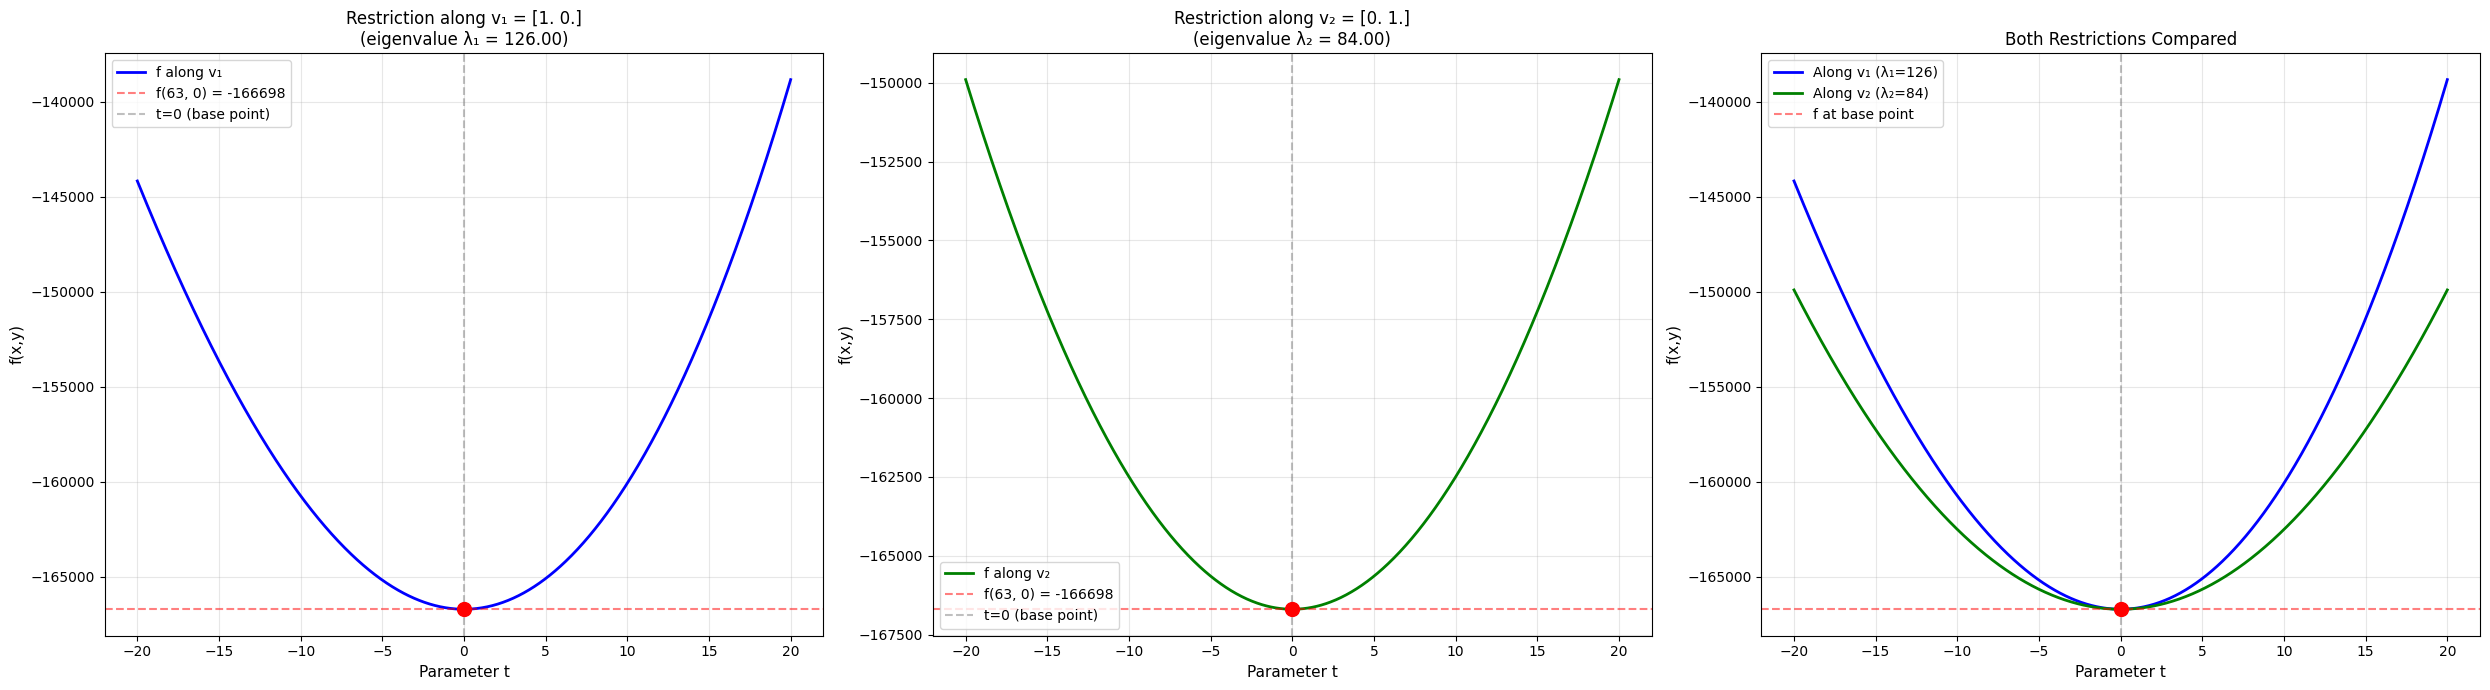

In [18]:
t = np.linspace(-20, 20, 1000)

def f_along_eigenvector(t: int, v: np.ndarray) -> int:
    """
    Evaluate f along the line (x0, y0) + t*v
    """
    x = x0 + t * v[0]
    y = y0 + t * v[1]
    return myfunc(x, y)

f_along_v1 = np.array([f_along_eigenvector(ti, eigenvectors[:, 0]) for ti in t])
f_along_v2 = np.array([f_along_eigenvector(ti, eigenvectors[:, 1]) for ti in t])

f_base = myfunc(x0, y0) # base value point

fig, axes = plt.subplots(1, 3, figsize=(25, 7))

# restriction along first eigenvector
ax1 = axes[0]
ax1.plot(t, f_along_v1, 'b-', linewidth=2, label=f'f along v₁')
ax1.axhline(y=f_base, color='r', linestyle='--', alpha=0.5, label=f'f({x0}, {y0}) = {f_base:.0f}')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='t=0 (base point)')
ax1.scatter([0], [f_base], color='red', s=100, zorder=5)
ax1.set_xlabel('Parameter t', fontsize=11)
ax1.set_ylabel('f(x,y)', fontsize=11)
ax1.set_title(f'Restriction along v₁ = {eigenvectors[:, 0]}\n(eigenvalue λ₁ = {eigenvalues[0]:.2f})', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# restriction along second eigenvector
ax2 = axes[1]
ax2.plot(t, f_along_v2, 'g-', linewidth=2, label=f'f along v₂')
ax2.axhline(y=f_base, color='r', linestyle='--', alpha=0.5, label=f'f({x0}, {y0}) = {f_base:.0f}')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='t=0 (base point)')
ax2.scatter([0], [f_base], color='red', s=100, zorder=5)
ax2.set_xlabel('Parameter t', fontsize=11)
ax2.set_ylabel('f(x,y)', fontsize=11)
ax2.set_title(f'Restriction along v₂ = {eigenvectors[:, 1]}\n(eigenvalue λ₂ = {eigenvalues[1]:.2f})', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# both restrictions
ax3 = axes[2]
ax3.plot(t, f_along_v1, 'b-', linewidth=2, label=f'Along v₁ (λ₁={eigenvalues[0]:.0f})')
ax3.plot(t, f_along_v2, 'g-', linewidth=2, label=f'Along v₂ (λ₂={eigenvalues[1]:.0f})')
ax3.axhline(y=f_base, color='r', linestyle='--', alpha=0.5, label=f'f at base point')
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.scatter([0], [f_base], color='red', s=100, zorder=5)
ax3.set_xlabel('Parameter t', fontsize=11)
ax3.set_ylabel('f(x,y)', fontsize=11)
ax3.set_title('Both Restrictions Compared', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Part II: Convexity (40 points)


# 1. Show $x^2+y^2+2xy-\ln{(xy)}$ is convex when  $x,y>0$ (5 points)

To prove that 

$$f(x,y) = x^2+y^2+2xy-\ln{(xy)}$$

is convex, we need to show that its Hessian is Positive Semidefinite (PDS), i.e. eigenvalues $\geq 0$ over the domain $x,y>0$. First we find the Hessian $H$:

\begin{align*}
\frac{\partial f}{\partial x} &= 2x + 2y - \frac{1}{x}, & \quad \frac{\partial f}{\partial y} &= 2y + 2x - \frac{1}{y} \\
\frac{\partial^2 f}{\partial x^2} &= 2 + \frac{1}{x^2}, & \quad \frac{\partial^2 f}{\partial y^2} &= 2 + \frac{1}{y^2} \\
\frac{\partial^2 f}{\partial x\partial y} &= 2, & \quad \frac{\partial^2 f}{\partial y\partial x} &= 2
\end{align*}

With this we have:

$$\nabla^2 f(x,y) = H = \begin{pmatrix} 2 + \frac{1}{x^2} & 2 \\ 2 & 2 + \frac{1}{y^2} \end{pmatrix}$$

We can now see that the Hessian $H$ is a **symmetric $2\times 2$ matrix**, and a unique property of these type of matrices is that if we satisfy the following properties:
1. Trace $\geq 0$
2. Determinant $\geq 0$

Then we will have $H$ being PSD. We can evaluate the two:

\begin{align*}
\text{det}(H) &= \left(2 + \frac{1}{x^2}\right)\left(2 + \frac{1}{y^2}\right) - 2(2) \\ 
&= 4 + \frac{2}{y^2} + \frac{2}{x^2} + \frac{1}{(xy)^2} - 4 \\
&= \frac{2x^2 + 2y^2 + 1}{(xy)^2} \geq 0 \quad (\text{for } x, y \geq 0)
\end{align*}

---

\begin{align*}
\text{Trace}(H) &= 2 + \frac{1}{x^2} + 2 + \frac{1}{y^2} \\
&= 4 + \frac{1}{x^2} + \frac{1}{y^2} \geq 0 \quad (\text{for } x, y \geq 0)
\end{align*}

With these 2 criteria met, we can say that $H$ is PSD, and thus $f(x,y)$ is **convex** when $x,y > 0$.

# 2. Show $-\log{(a^\top x+b)}$ is convex (5 points)

From the lecture, we know that the function $f(x) = \log(x)$ is concave on $\mathbb{R}_{++}$. As a result, $-\log(\cdot)$ is thus a convex function on $(0,\infty)$, where the domain for $f(x)$ is restricted to:

$$\mathcal{D} = \{x \in \mathbb{R}^n : a^\top x + b > 0\}$$

since **$f(x)$ is only defined when the argument is positive**. Namely, $-\log(x)$ is twice differentiable and second derivative is non-negative:

\begin{align*}
f'(x) &= -\frac{1}{x \ln (10)} \\
&= \frac{1}{x^2 \ln (10)} \geq 0
\end{align*}


Furthermore, $f(x)$ is obtained by composing $-\log(\cdot)$ with an affine function (i.e. $(a^\top x + b)$), and we know that from properties of convex functions, **composing a convex function with an affine map yields a convex function**. Since $a^\top x + b$ is affine and maps $\mathcal{D}$ into $(0, \infty)$, then we can say that $f(x) = -\log(a^\top x + b)$ is convex on $\mathcal{D}$.

# 3. If $f$ is convex, which of the two sets is always convex  $\{x:f(x)\geq 0 \}$ or $\{x:f(x)\leq 0 \}$? (5 points)

If $f$ is convex, the **sublevel set** is always convex, i.e.

$$\{x:f(x) \leq 0\}$$

Proof:

Assume $f$ is convex on a convex domain $\mathcal{C}$. We can take any two points $x,y \in \mathcal{C}$ with $f(x) \leq 0$ and $f(y) \leq 0$. For any $\lambda \in [0,1]$, convexity of $f$ gives us:

\begin{align*}
f((1-\lambda)x + \lambda y) &\leq (1-\lambda) f(x) + \lambda f(y)  \\
& \leq (1-\lambda)\cdot 0 + \lambda (0) \\
&= 0
\end{align*}

by **Jensen's inequality**. Thus, we have that $(1-\lambda)x + \lambda y$ belongs to the set $\{x : f(x) \leq 0\}$. Since any convex combination of two arbitrary points in the set remains in the set, then the set is convex.

# 4. Is the set $\{(x,y):x^2+y^2\geq 1\}$ convex? Answer Yes/No (5 points)

The set $\mathcal{S} = \{(x,y): x^2 + y^2 \geq 1\}$ is the exterior (including the circle) of the unit disk. Intuitively, we can have two points on the opposite side of the circle that has a segment that passes through the interior of the disk, so the exterior is not closed under convex combinations, so it is **not convex**. 

To prove this:

Consider two points $u = (1,0)$ and $v = (-1,0)$. Both satisfy:

\begin{align*}u^2 + 0^2 = 1, & \quad v^2 + 0^2 = 1\end{align*}

so we have $u, v \in \mathcal{S}$. The midpoint is given by:

$$\frac{u + v}{2} = (0,0)$$

but we have $0^2 + 0^2 = 0 < 1$, so we know that $(0,0) \notin \mathcal{S}$. As the line segment joining the two points of $\mathcal{S}$ can leave $\mathcal{S}$, then we know that $\mathcal{S}$ **is not convex**.

# 5. A random variable $X$ takes values $100$ or $400$ with equal probability (5 points) 

  a. Let the utility function be $f(x) = \sqrt{x}$.  
   
   - Compute $\mathbb{E}[X]$.  
   - Compare $f(\mathbb{E}[X])$ with $\mathbb{E}[f(X)]$.  
   - What does the inequality tell you about risk attitudes captured by $f$?  

  b. Repeat the same steps with the convex utility function $f(x) = x^2$.  
  
   - Does the inequality reverse?  
   - How does this reflect different risk preferences?  



---

Answer:

(a) Since $X$ takes values 100 or 400 with equal probabilties, we have:

\begin{align*}\mathbb{P}(X = 100) = \frac{1}{2}, & \quad \mathbb{P}(X = 400) = \frac{1}{2}\end{align*}

The expectation is given by:

\begin{align*}
\mathbb{E}[X] &= \sum_x x \mathbb{P}(X = x) \\
&= 100 \cdot \frac{1}{2} + 400 \cdot \frac{1}{2} \\
&= 250
\end{align*}

Now we compare the two:

$$f(\mathbb{E}[X]) = \sqrt{250} \approx 15.811$$

\begin{align*}
\mathbb{E}[f(X)] &= \frac{1}{2} \sqrt{100} + \frac{1}{2}\sqrt{400} \\ 
&=\frac{1}{2} (10 + 20) \\
&= 15
\end{align*}

So we have that $f(\mathbb{E}[X]) > \mathbb{E}[f(X)]$, which is consistent with Jensen's inequality for statistical interpretation. The interpretation here suggests that a **concave** utility function $f$ models **risk aversion**, where $\sqrt{\cdot}$ is concave. This means that the decision maker prefers the *utility of the expected outcome* to the expected utility of risky outcomes. 

The inequality shows that the agent would rather have the guaranteed amount of 250 than risk the 50/50 gamble between 100 and 400, despite both having the same expectation, thus modelling risk aversion.

---

Answer:

(b) This time for $f(x) = x^2$, we have $\mathbb{E}[X]$ remains the same, so:

$$
\mathbb{E}[X] = 250
$$

Now we compare the two:

$$f(\mathbb{E}[X]) = 250^2 = 62500$$

\begin{align*}
\mathbb{E}[f(X)] &= \frac{1}{2} 100^2 + \frac{1}{2} 400^2 \\ 
&=\frac{1}{2} (100^2 + 400^2) \\
&= 85000
\end{align*}

We can see that here $\mathbb{E}[f(X)] > f(\mathbb{E}[X])$, so the inequality indeed reverses, which is consistent with Jensen's inequality direction for a convex $f$. 

This reflects different risk preferences as a convex function $f(x) = x^2$ models **risk-seeking** behaviour, so the decision-maker assigns *higher utility to the risky lottery (50/50 gamble) than to the guaranteed amount of $\mathbb{E}(X) = 250$*.

# 6. Are linear function convex or concave? Explain (5 points)

A linear function (affine) is actually **both convex and concave**. Let's say that $x \ in \mathbb{R}^n$, so we have the affine function:

$$f(x) = a^\top x + b$$

We consider Jensen's inequality which defines a convex function:

$$f((1 - \lambda)x + \lambda y) \leq (1-\lambda)f(x) + \lambda f(y), \quad \forall x, y \in \mathbb{R}^n \; \wedge \; \forall \lambda \in [0,1]$$

So for the affine function $f(x)$ we have:

\begin{align*}
f((1 - \lambda)x + \lambda y) &= a^\top ((1-\lambda)x + \lambda y) + b \\
&= (1-\lambda)(a^\top x + b) + \lambda (a^\top y + b) \\
&= (1-\lambda) f(x) + \lambda f(y)
\end{align*}

so we can see that the convexity inequality holds, with equality. So $f$ is convex. 

Now for **concavity**, we can perform the same operations, but with reversed inequality:

$$f((1 - \lambda)x + \lambda y) \geq (1-\lambda)f(x) + \lambda f(y), \quad \forall x, y \in \mathbb{R}^n \; \wedge \; \forall \lambda \in [0,1]$$

\begin{align*}
f((1 - \lambda)x + \lambda y) &= a^\top ((1-\lambda)x + \lambda y) + b \\
&= (1-\lambda)(a^\top x + b) + \lambda (a^\top y + b) \\
&= (1-\lambda) f(x) + \lambda f(y)
\end{align*}

So the same computation for concavity inequality holds (with equality), so $f$ is also concave, thus we can say that the linear function (affine) is **both convex and concave**.

# 7. Quadratic Forms and Convexity (10 points)

Consider the function in two variables  

$$
f(x_1, x_2) = 3x_1^2 + 2x_1x_2 + 4x_2^2 - 5x_1 + 6x_2 + 7.
$$

1. Rewrite $f(x_1, x_2)$ in quadratic form as  

$$
f(x) = \frac{1}{2} x^\top A x + b^\top x + c,
$$

where $x = (x_1, x_2)^\top$, $A$ is a symmetric matrix, $b$ is a vector, and $c$ is a constant.  

2. Compute the Hessian $\nabla^2 f(x)$.  

3. Determine whether $f$ is convex, concave, or neither, by checking the definiteness of $A$.


---
Answer

(1) To rewrite $f(x_1,x_2)$ in quadratic form, we first consider the constant term:

By observation, we have 

$$c = 7$$

Next for the linear terms, we need $b^\top x = -5x_1 + 6x_2$, so we have:

$$b = \begin{bmatrix} -5 \\ 6 \end{bmatrix}$$

Lastly for the quadratic terms, the general part of $\frac{1}{2} x^\top A x$ is:

$$\frac{1}{2}x^\top \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} x = \frac{1}{2}(a_{11}x_1^2 + (a_{12} + a_{21}) x_1 x_2 + a_{22}x^2_2)$$

By comparison, we have

$$3x_1^2 + 2x_1 x_2 + 4x_2^2$$

so this gives us $A$ as follows:

$$A = \begin{bmatrix} 6 & 2 \\ 2 & 8 \end{bmatrix}$$

The final quadratic form is thus:

$$f(x) = \frac{1}{2} x^\top \begin{bmatrix} 6 & 2 \\ 2 & 8 \end{bmatrix} x + \begin{bmatrix} -5 \\ 6 \end{bmatrix}^\top x + 7$$

---
Answer

(b) We know the following:

$$
f(x) = \frac{1}{2} x^\top A x + b^\top x + c
$$

Here we compute the gradient:

\begin{align*} \nabla f(x) &= \nabla \left(\frac{1}{2} x^\top A x + b^\top x + c\right) \\
&= Ax + b
\end{align*}

And the Hessian:

\begin{align*}
\nabla^2 f(x) &= \nabla\left(\nabla f(x)\right) \\
&= \nabla (Ax + b) \\
&= A
\end{align*}

So we know the Hessian $\nabla^2 f(x)$ is just given by $A$, which is:

$$\nabla^2 f(x) = A = \begin{bmatrix} 6 & 2 \\ 2 & 8 \end{bmatrix}$$

---
Answer

(c) To check the definiteness of A, we note again that $A$ is a symmetric $2 \times 2$ matrix, so it is PSD if its determinant and trace is both $\geq 0$. Evaluating the two:

1. $\text{Determinant} = 6(8) - 2(2) = 44 \geq 0$
2. $\text{Trace} = 6 + 8 = 14 \geq 0$ 

With these two conditions met, we can guarantee that $A$ is PSD, and $f$ is a convex function.